In [4]:
import netCDF4 as nc
import wrf
import numpy as np 
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle
import pickle

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/wrf/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [1]:
# Paths
path_wrf     = "/g/data/up6/ai2733/WRF_real/WRF/"
path_figs    = "/g/data/up6/ai2733/Gusts_downdrafts/figures/Figures/"
path_domains = "/g/data/up6/ai2733/Gusts_downdrafts/data/wps_domains/"


In [2]:
# General info
path_figs = "/g/data/up6/ai2733/Codes/Figures/"
date_cases    = {"CASE1": ("2015-12-15", "2015-12-16"), 
                 "CASE2_new": ("2009-01-19","2009-01-20"), 
                 "CASE3_new": ("2017-02-16","2017-02-17")}
lat_lon_cases = {"CASE1": (-29.49, 149.85), 
                "CASE2_new": (-35.16, 147.46), 
                 "CASE3_new": (-31.07,150.84)}
name_cases    = {"CASE1":     "Moree Aero",
                 "CASE2_new": "Wagga Wagga", 
                 "CASE3_new": "Tamworth Airport"}


## Figure 1a


In [7]:
cases = ["CASE1", "CASE2_new", "CASE3_new"]

In [8]:
# Read WRF domains
with open(f'{path_domains}/extent_d3.pkl', 'rb') as f:
    extent_d3 = pickle.load(f)

with open(f'{path_domains}/extent_d2.pkl', 'rb') as f:
    extent_d2 = pickle.load(f)

with open(f'{path_domains}/extent_d1.pkl', 'rb') as f:
    extent_d1 = pickle.load(f)

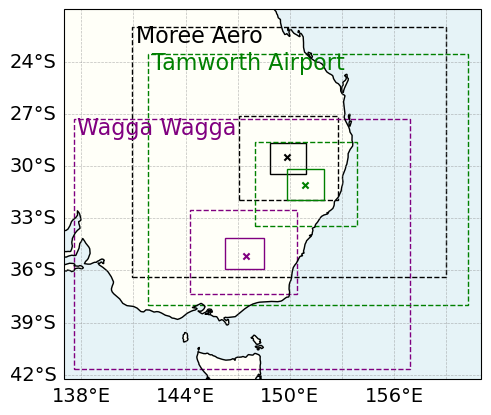

In [9]:
# Plot all domains
fs = 16
fig = plt.figure()

usemap_proj = ccrs.PlateCarree()
ax = plt.axes(projection=usemap_proj)

# Plot WRF domains
color_cases = {"CASE1":"k", 
              "CASE2_new": "purple", 
              "CASE3_new":"green"}

# Add BOM stations
for case in cases:
    scatter1 = ax.scatter(lat_lon_cases[case][1],lat_lon_cases[case][0], marker = "x", facecolor = color_cases[case], linewidths = 1.5, s = 20., transform=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, color='lightyellow', alpha = 0.2)
ax.add_feature(cfeature.OCEAN, color='lightblue', alpha = 0.3)
ax.add_feature(cfeature.COASTLINE)
gl = ax.gridlines(crs=ccrs.PlateCarree(), x_inline=False, y_inline=False, draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels   = False  # Hide labels on the upper side
gl.right_labels = False  
gl.xlabel_style = {'size': 14}  # Or any desired fontsize
gl.ylabel_style = {'size': 14}

for case in cases:
    lon1_d3, lon2_d3, lat1_d3, lat2_d3 = extent_d3[case]
    rectangle_d3 = Rectangle((lon1_d3, lat1_d3), lon2_d3 - lon1_d3, lat2_d3 - lat1_d3, linewidth=1.0, edgecolor=color_cases[case], facecolor='none', transform=ccrs.PlateCarree())

    lon1_d2, lon2_d2, lat1_d2, lat2_d2 = extent_d2[case]
    rectangle_d2 = Rectangle((lon1_d2, lat1_d2), lon2_d2 - lon1_d2, lat2_d2 - lat1_d2, linewidth=1.0, ls = "--", edgecolor=color_cases[case], facecolor='none', transform=ccrs.PlateCarree())

    lon1_d1, lon2_d1, lat1_d1, lat2_d1 = extent_d1[case]
    rectangle_d1 = Rectangle((lon1_d1, lat1_d1), lon2_d1 - lon1_d1, lat2_d1 - lat1_d1, linewidth=1.0, ls = "--", edgecolor=color_cases[case], facecolor='none', transform=ccrs.PlateCarree())
    
    ax.add_patch(rectangle_d3)
    ax.add_patch(rectangle_d2)
    ax.add_patch(rectangle_d1)
    
    text_x = lon1_d1 + 0.2  # small offset to the right
    text_y = lat2_d1 - 0.89  # small offset down from top edge
    ax.text(text_x, text_y, name_cases[case], fontsize=fs,
            color=color_cases[case], transform=ccrs.PlateCarree(),
            bbox=dict(facecolor='white', alpha=0.0, edgecolor='none', boxstyle='round,pad=0.2'))

ax.set_ylabel("Longitude")
ax.set_ylabel("Latitude")

extent_box = [137., 161.0, -42.0, -21.0]
xmin, xmax, ymin, ymax = extent_box
ax.set_extent(extent_box)
plt.savefig(f"{path_figs}Figure1a.png", dpi = 600,  bbox_inches='tight')
plt.show()
